# Notebook 05 — Cu–Zr potential validation (multiple MACE / ACE / EAM candidates)

This notebook validates the currently available Cu–Zr potentials in a structured way:

1. **Potential smoke test**
   - confirm each potential loads in pyiron/LAMMPS
   - static energy/force evaluation
   - very short MD sanity run

2. **Crystalline validation**
   - FCC Cu equation-of-state style scan
   - HCP Zr equation-of-state style scan
   - B2 CuZr equation-of-state style scan

3. **Amorphous / NCL-oriented validation**
   - melt → quench → minimize
   - short NVE drift check
   - optional isotropic compression test

The notebook is written so that **MACE + two EAMs** run now, while **ACE** can be dropped into the same workflow later.


## 0. Environment switch

Convention kept consistent with your other notebooks:

- `MODE = True`  → laptop / DEV
- `MODE = False` → A100 / larger production-style runs


In [1]:
MODE = True   # True on laptop, False on A100


## 1. Imports and project setup


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

from pyiron_atomistics import Project
from pyiron_atomistics.atomistics.structure.atoms import Atoms

# Multi-potential setup helper (supports several MACE and ACE models in one array)
import cuzr_setup_multi as cz

pr = Project("../cu_zr_mlip_project")
pr


{'groups': [], 'nodes': ['mace_md_test', 'sanity_static_Cu_MACE', 'sanity_static_Cu_2007_MendelevmMmI_CumZr_LAMMPS_ipr1', 'sanity_static_Cu_EAM_Mendelev_2019_CuZr', 'ncl05_sanity_static_B2_MACE', 'ncl05_static_sanity_MACE', 'ncl05_melt_MACE', 'dev_melt_MACE', 'dev_eos_FCC_Cu_00_MACE', 'dev_eos_FCC_Cu_01_MACE', 'dev_eos_FCC_Cu_02_MACE', 'dev_eos_FCC_Cu_03_MACE', 'dev_eos_FCC_Cu_04_MACE', 'dev_eos_FCC_Cu_05_MACE', 'dev_eos_FCC_Cu_06_MACE', 'dev_eos_HCP_Zr_00_MACE', 'dev_eos_HCP_Zr_01_MACE', 'dev_eos_HCP_Zr_02_MACE', 'dev_eos_HCP_Zr_03_MACE', 'dev_eos_HCP_Zr_04_MACE', 'dev_eos_HCP_Zr_05_MACE', 'dev_eos_HCP_Zr_06_MACE', 'dev_eos_B2_CuZr_00_MACE', 'dev_eos_B2_CuZr_01_MACE', 'dev_eos_B2_CuZr_02_MACE', 'dev_eos_B2_CuZr_03_MACE', 'dev_eos_B2_CuZr_04_MACE', 'dev_eos_B2_CuZr_05_MACE', 'dev_eos_B2_CuZr_06_MACE', 'dev_eos_FCC_Cu_00_EAM_Mendelev_2019_CuZr', 'dev_eos_FCC_Cu_01_EAM_Mendelev_2019_CuZr', 'dev_eos_FCC_Cu_02_EAM_Mendelev_2019_CuZr', 'dev_eos_FCC_Cu_03_EAM_Mendelev_2019_CuZr', 'dev_eos_FC

## 2. Threading / local runtime knobs

These environment variables matter mostly for the local laptop case.


In [3]:
import os

if MODE:
    os.environ["OMP_NUM_THREADS"] = "6"
    os.environ["MKL_NUM_THREADS"] = "1"
    os.environ["OPENBLAS_NUM_THREADS"] = "1"
    os.environ["VECLIB_MAXIMUM_THREADS"] = "1"


## 3. Define the unified potential list

This notebook is now driven by **one explicit array of potentials**.

That list can contain:
- multiple MACE candidates
- multiple ACE candidates
- EAM baselines

You edit only `POTENTIAL_SPECS` below, then register it once in the helper.


In [4]:
# --- Unified potential list for Notebook 05 ---
# Keep everything in one array so the validation notebook is easy to read and edit.

POTENTIAL_SPECS = [
    # MACE candidates
    cz.make_mace_spec("MACE_A", "CuZr_MACE_A_compiled.model-lammps.pt"),
    cz.make_mace_spec("MACE_B", "CuZr_MACE_B_compiled.model-lammps.pt"),
    cz.make_mace_spec("MACE_C", "CuZr_MACE_C_compiled.model-lammps.pt"),
    cz.make_mace_spec("MACE_D", "CuZr_MACE_D_compiled.model-lammps.pt"),

    # EAM baselines
    cz.make_pyiron_spec("EAM_Mendelev_2019_CuZr", "EAM_Mendelev_2019_CuZr__MO_945018740343_000"),
    cz.make_pyiron_spec("2007_Mendelev-M-I_Cu-Zr_LAMMPS_ipr1", "2007--Mendelev-M-I--Cu-Zr--LAMMPS--ipr1"),

    # ACE candidates (activate when the exported ACE models are ready)
    # cz.make_ace_spec("ACE_A", "CuZr_ACE_A.yace"),
    # cz.make_ace_spec("ACE_B", "CuZr_ACE_B.yace"),
    # cz.make_ace_spec("ACE_C", "CuZr_ACE_C.yace"),
    # cz.make_ace_spec("ACE_D", "CuZr_ACE_D.yace"),
]

cz.register_potentials(POTENTIAL_SPECS)

pd.DataFrame([
    {
        "id": p["id"],
        "mode": p["mode"],
        "family": p.get("family", ""),
        "name": p.get("name", ""),
        "model_file": p.get("model_file", ""),
    }
    for p in cz.POTENTIALS
])



,id,mode,name
0,MACE,custom,None
1,2007_Mendelev-M-I_Cu-Zr_LAMMPS_ipr1,pyiron,2007--Mendelev-M-I--Cu-Zr--LAMMPS--ipr1
2,EAM_Mendelev_2019_CuZr,pyiron,EAM_Mendelev_2019_CuZr__MO_945018740343_000
3,ACE,placeholder,None


## 4. Pick which potentials to run

By default we run everything registered in `POTENTIAL_SPECS`.

If you want a smaller subset, replace `POTS_TO_RUN = list(cz.POTENTIALS)`
with a filtered list of ids.


In [5]:
def pot(id_):
    return cz.pot(id_)

# Default: run every registered potential
POTS_TO_RUN = list(cz.POTENTIALS)

# Example for a smaller subset:
# POTS_TO_RUN = [pot("MACE_A"), pot("MACE_B"), pot("EAM_Mendelev_2019_CuZr")]

pd.DataFrame([
    {
        "id": p["id"],
        "mode": p["mode"],
        "family": p.get("family", ""),
        "name": p.get("name", ""),
        "model_file": p.get("model_file", ""),
    }
    for p in POTS_TO_RUN
])



,id,mode,name
0,MACE,custom,None
1,EAM_Mendelev_2019_CuZr,pyiron,EAM_Mendelev_2019_CuZr__MO_945018740343_000
2,2007_Mendelev-M-I_Cu-Zr_LAMMPS_ipr1,pyiron,2007--Mendelev-M-I--Cu-Zr--LAMMPS--ipr1


## 5. Global parameters

The notebook is organized so that **smoke tests are cheap**, while the amorphous/NCL part scales with `MODE`.


In [6]:
CORES = 1 if MODE else 4

# very small validation jobs first
SMOKE_MD_STEPS = 50 if MODE else 200
SMOKE_THERMO = 10 if MODE else 20

# EOS scans
EOS_POINTS = 7
EOS_SCALES = np.linspace(0.96, 1.04, EOS_POINTS)

# amorphous / NCL-oriented block
T_MELT = 2000

if MODE:
    STEPS_MELT = 500
    QUENCH_TS = (1200, 600, 300)
    STEPS_EACH = 500
    NVE_STEPS = 1000
    THERMO = 100
    DUMP_EVERY = 10
    NEIGH_EVERY = 10
else:
    STEPS_MELT = 30000
    QUENCH_TS = (1500, 1000, 700, 500, 300)
    STEPS_EACH = 20000
    NVE_STEPS = 20000
    THERMO = 1000
    DUMP_EVERY = 5000
    NEIGH_EVERY = 10

print("MODE =", MODE)
print("CORES =", CORES)
print("SMOKE_MD_STEPS =", SMOKE_MD_STEPS)
print("T_MELT =", T_MELT)
print("QUENCH_TS =", QUENCH_TS)


MODE = True
CORES = 1
SMOKE_MD_STEPS = 50
T_MELT = 2000
QUENCH_TS = (1200, 600, 300)


## 6. Structure builders

We validate both **crystalline** and **amorphous** behavior.

Crystalline:
- FCC Cu
- HCP Zr
- B2 CuZr

Amorphous/NCL seed:
- repeated B2 cell, later melted


In [7]:
def make_fcc_cu(a=3.615, rep=(4, 4, 4)):
    basis = Atoms(
        symbols=["Cu"] * 4,
        positions=[
            [0.0, 0.0, 0.0],
            [0.0, 0.5*a, 0.5*a],
            [0.5*a, 0.0, 0.5*a],
            [0.5*a, 0.5*a, 0.0],
        ],
        cell=[a, a, a],
        pbc=True,
    )
    return basis.repeat(rep)

def make_hcp_zr(a=3.23, c_over_a=1.593, rep=(4, 4, 3)):
    c = c_over_a * a
    cell = np.array([
        [a, 0.0, 0.0],
        [0.5*a, np.sqrt(3)/2*a, 0.0],
        [0.0, 0.0, c],
    ])
    basis = Atoms(
        symbols=["Zr", "Zr"],
        scaled_positions=[
            [0.0, 0.0, 0.0],
            [2/3, 1/3, 1/2],
        ],
        cell=cell,
        pbc=True,
    )
    return basis.repeat(rep)

def make_b2_cuzr(a=3.2, rep=(6, 6, 6)):
    structure = Atoms(
        symbols=["Cu", "Zr"],
        positions=[
            [0.0, 0.0, 0.0],
            [0.5*a, 0.5*a, 0.5*a],
        ],
        cell=[a, a, a],
        pbc=True,
    )
    return structure.repeat(rep)

def make_glass_seed(a=3.2, rep=(8, 4, 4)):
    return make_b2_cuzr(a=a, rep=rep)

fcc_cu = make_fcc_cu()
hcp_zr = make_hcp_zr()
b2_cuzr = make_b2_cuzr()
glass_seed = make_glass_seed()

{
    "fcc_cu_atoms": len(fcc_cu),
    "hcp_zr_atoms": len(hcp_zr),
    "b2_cuzr_atoms": len(b2_cuzr),
    "glass_seed_atoms": len(glass_seed),
}


{'fcc_cu_atoms': 256,
 'hcp_zr_atoms': 96,
 'b2_cuzr_atoms': 432,
 'glass_seed_atoms': 256}

## 7. Helpers


In [8]:
def jname(prefix, pot_spec):
    run_tag = "dev" if MODE else "prod"
    return f"{run_tag}_{prefix}_{pot_spec['id']}"

def isotropic_scale(structure, scale):
    s = structure.copy()
    s.set_cell(np.array(s.cell) * scale, scale_atoms=True)
    return s

def get_last_energy(job):
    try:
        return float(job.output.energy_pot[-1])
    except Exception:
        try:
            return float(job.output.energy_tot[-1])
        except Exception:
            return np.nan

def get_last_temp(job):
    try:
        return float(job.output.temperature[-1])
    except Exception:
        return np.nan

def get_last_press(job):
    for attr in ["pressures", "pressure", "press"]:
        try:
            arr = getattr(job.output, attr)
            return float(arr[-1])
        except Exception:
            pass
    return np.nan

def static_summary(job, label, pot_id, structure_name, scale=None):
    return {
        "label": label,
        "pot_id": pot_id,
        "structure": structure_name,
        "scale": scale,
        "n_atoms": len(job.structure),
        "energy_last_eV": get_last_energy(job),
        "energy_per_atom_eV": get_last_energy(job) / len(job.structure),
    }

def md_summary(job, label, pot_id, structure_name):
    return {
        "label": label,
        "pot_id": pot_id,
        "structure": structure_name,
        "n_atoms": len(job.structure),
        "energy_last_eV": get_last_energy(job),
        "energy_per_atom_eV": get_last_energy(job) / len(job.structure),
        "temp_last_K": get_last_temp(job),
        "press_last": get_last_press(job),
    }


## 8. Potential smoke test

This is the first thing to run after introducing a new potential file.

For each potential:
- static calculation on B2 CuZr
- very short MD at 300 K

This confirms that the MACE model is readable by pyiron/LAMMPS and behaves sanely before we launch expensive jobs.


In [9]:
smoke_rows = []

for p in POTS_TO_RUN:
    print("SMOKE TEST:", p["id"])

    # static
    j_static = cz.run_static(
        pr=pr,
        job_name=jname("smoke_static_b2", p),
        structure=b2_cuzr,
        pot_spec=p,
        cores=CORES,
        delete_existing=True,
    )
    smoke_rows.append(static_summary(j_static, "smoke_static", p["id"], "B2_CuZr"))

    # short MD
    j_md = cz.run_md(
        pr=pr,
        job_name=jname("smoke_md_b2", p),
        structure=b2_cuzr,
        pot_spec=p,
        T=300,
        steps=SMOKE_MD_STEPS,
        timestep_fs=1.0,
        cores=CORES,
        delete_existing=True,
        thermo=SMOKE_THERMO,
        dump_every=10,
        neigh_every=10,
    )
    smoke_rows.append(md_summary(j_md, "smoke_md", p["id"], "B2_CuZr"))

smoke_df = pd.DataFrame(smoke_rows)
smoke_df


SMOKE TEST: MACE
The job dev_smoke_static_b2_MACE was saved and received the ID: 112


2026-03-13 12:57:41,603 - pyiron_log - WARNING - Job 'dev_smoke_md_b2_MACE' does not exist and cannot be loaded


The job dev_smoke_md_b2_MACE was saved and received the ID: 113
SMOKE TEST: EAM_Mendelev_2019_CuZr
The job dev_smoke_static_b2_EAM_Mendelev_2019_CuZr was saved and received the ID: 114


2026-03-13 13:01:03,124 - pyiron_log - WARNING - Job 'dev_smoke_md_b2_EAM_Mendelev_2019_CuZr' does not exist and cannot be loaded


The job dev_smoke_md_b2_EAM_Mendelev_2019_CuZr was saved and received the ID: 115
SMOKE TEST: 2007_Mendelev-M-I_Cu-Zr_LAMMPS_ipr1
The job dev_smoke_static_b2_2007_MendelevmMmI_CumZr_LAMMPS_ipr1 was saved and received the ID: 116


2026-03-13 13:01:04,129 - pyiron_log - WARNING - Job 'dev_smoke_md_b2_2007_MendelevmMmI_CumZr_LAMMPS_ipr1' does not exist and cannot be loaded


The job dev_smoke_md_b2_2007_MendelevmMmI_CumZr_LAMMPS_ipr1 was saved and received the ID: 117


,label,pot_id,structure,scale,n_atoms,energy_last_eV,energy_per_atom_eV,temp_last_K,press_last
0,smoke_static,MACE,B2_CuZr,NaN,432,-2157.116913,-4.993326,NaN,NaN
1,smoke_md,MACE,B2_CuZr,NaN,432,-2131.527356,-4.934091,114.347664,NaN
2,smoke_static,EAM_Mendelev_2019_CuZr,B2_CuZr,NaN,432,-2169.177477,-5.021244,NaN,NaN
3,smoke_md,EAM_Mendelev_2019_CuZr,B2_CuZr,NaN,432,-2149.042602,-4.974636,199.368525,NaN
4,smoke_static,2007_Mendelev-M-I_Cu-Zr_LAMMPS_ipr1,B2_CuZr,NaN,432,-2163.922952,-5.009081,NaN,NaN
5,smoke_md,2007_Mendelev-M-I_Cu-Zr_LAMMPS_ipr1,B2_CuZr,NaN,432,-2140.409919,-4.954653,147.939225,NaN


## 9. Crystalline validation — EOS-style scans

These are lightweight but scientifically meaningful checks:
- FCC Cu
- HCP Zr
- B2 CuZr

We scan isotropic volume changes and compare energy/atom curves across potentials.


In [10]:
def run_eos_scan(pr, structure, structure_name, pot_spec, scales=EOS_SCALES, cores=CORES):
    rows = []
    for i, s in enumerate(scales):
        struct_s = isotropic_scale(structure, float(s))
        job = cz.run_static(
            pr=pr,
            job_name=jname(f"eos_{structure_name}_{i:02d}", pot_spec),
            structure=struct_s,
            pot_spec=pot_spec,
            cores=cores,
            delete_existing=False,
        )
        rows.append(static_summary(job, "eos", pot_spec["id"], structure_name, scale=float(s)))
    return pd.DataFrame(rows)

eos_frames = []
for p in POTS_TO_RUN:
    print("EOS:", p["id"])
    eos_frames.append(run_eos_scan(pr, fcc_cu, "FCC_Cu", p))
    eos_frames.append(run_eos_scan(pr, hcp_zr, "HCP_Zr", p))
    eos_frames.append(run_eos_scan(pr, b2_cuzr, "B2_CuZr", p))

eos_df = pd.concat(eos_frames, ignore_index=True)
eos_df.head()


2026-03-13 13:01:04,787 - pyiron_log - WARNING - The job dev_eos_FCC_Cu_00_MACE is being loaded instead of running. To re-run use the argument 'delete_existing_job=True in create_job'
2026-03-13 13:01:04,826 - pyiron_log - WARNING - The job dev_eos_FCC_Cu_01_MACE is being loaded instead of running. To re-run use the argument 'delete_existing_job=True in create_job'
2026-03-13 13:01:04,865 - pyiron_log - WARNING - The job dev_eos_FCC_Cu_02_MACE is being loaded instead of running. To re-run use the argument 'delete_existing_job=True in create_job'
2026-03-13 13:01:04,903 - pyiron_log - WARNING - The job dev_eos_FCC_Cu_03_MACE is being loaded instead of running. To re-run use the argument 'delete_existing_job=True in create_job'
2026-03-13 13:01:04,941 - pyiron_log - WARNING - The job dev_eos_FCC_Cu_04_MACE is being loaded instead of running. To re-run use the argument 'delete_existing_job=True in create_job'


EOS: MACE


2026-03-13 13:01:04,980 - pyiron_log - WARNING - The job dev_eos_FCC_Cu_05_MACE is being loaded instead of running. To re-run use the argument 'delete_existing_job=True in create_job'
2026-03-13 13:01:05,018 - pyiron_log - WARNING - The job dev_eos_FCC_Cu_06_MACE is being loaded instead of running. To re-run use the argument 'delete_existing_job=True in create_job'
2026-03-13 13:01:05,056 - pyiron_log - WARNING - The job dev_eos_HCP_Zr_00_MACE is being loaded instead of running. To re-run use the argument 'delete_existing_job=True in create_job'
2026-03-13 13:01:05,094 - pyiron_log - WARNING - The job dev_eos_HCP_Zr_01_MACE is being loaded instead of running. To re-run use the argument 'delete_existing_job=True in create_job'
2026-03-13 13:01:05,133 - pyiron_log - WARNING - The job dev_eos_HCP_Zr_02_MACE is being loaded instead of running. To re-run use the argument 'delete_existing_job=True in create_job'
2026-03-13 13:01:05,171 - pyiron_log - WARNING - The job dev_eos_HCP_Zr_03_MACE 

EOS: EAM_Mendelev_2019_CuZr


2026-03-13 13:01:05,818 - pyiron_log - WARNING - The job dev_eos_FCC_Cu_05_EAM_Mendelev_2019_CuZr is being loaded instead of running. To re-run use the argument 'delete_existing_job=True in create_job'
2026-03-13 13:01:05,861 - pyiron_log - WARNING - The job dev_eos_FCC_Cu_06_EAM_Mendelev_2019_CuZr is being loaded instead of running. To re-run use the argument 'delete_existing_job=True in create_job'
2026-03-13 13:01:05,905 - pyiron_log - WARNING - The job dev_eos_HCP_Zr_00_EAM_Mendelev_2019_CuZr is being loaded instead of running. To re-run use the argument 'delete_existing_job=True in create_job'
2026-03-13 13:01:05,949 - pyiron_log - WARNING - The job dev_eos_HCP_Zr_01_EAM_Mendelev_2019_CuZr is being loaded instead of running. To re-run use the argument 'delete_existing_job=True in create_job'
2026-03-13 13:01:05,992 - pyiron_log - WARNING - The job dev_eos_HCP_Zr_02_EAM_Mendelev_2019_CuZr is being loaded instead of running. To re-run use the argument 'delete_existing_job=True in cr

EOS: 2007_Mendelev-M-I_Cu-Zr_LAMMPS_ipr1


2026-03-13 13:01:06,739 - pyiron_log - WARNING - The job dev_eos_FCC_Cu_05_2007_MendelevmMmI_CumZr_LAMMPS_ipr1 is being loaded instead of running. To re-run use the argument 'delete_existing_job=True in create_job'
2026-03-13 13:01:06,782 - pyiron_log - WARNING - The job dev_eos_FCC_Cu_06_2007_MendelevmMmI_CumZr_LAMMPS_ipr1 is being loaded instead of running. To re-run use the argument 'delete_existing_job=True in create_job'
2026-03-13 13:01:06,826 - pyiron_log - WARNING - The job dev_eos_HCP_Zr_00_2007_MendelevmMmI_CumZr_LAMMPS_ipr1 is being loaded instead of running. To re-run use the argument 'delete_existing_job=True in create_job'
2026-03-13 13:01:06,870 - pyiron_log - WARNING - The job dev_eos_HCP_Zr_01_2007_MendelevmMmI_CumZr_LAMMPS_ipr1 is being loaded instead of running. To re-run use the argument 'delete_existing_job=True in create_job'
2026-03-13 13:01:06,913 - pyiron_log - WARNING - The job dev_eos_HCP_Zr_02_2007_MendelevmMmI_CumZr_LAMMPS_ipr1 is being loaded instead of ru

,label,pot_id,structure,scale,n_atoms,energy_last_eV,energy_per_atom_eV
0,eos,MACE,FCC_Cu,0.960000,256,-842.997759,-3.292960
1,eos,MACE,FCC_Cu,0.973333,256,-866.347592,-3.384170
2,eos,MACE,FCC_Cu,0.986667,256,-883.530079,-3.451289
3,eos,MACE,FCC_Cu,1.000000,256,-894.962853,-3.495949
4,eos,MACE,FCC_Cu,1.013333,256,-901.118276,-3.519993


### Optional quick plots for EOS scans


   label                               pot_id structure     scale  n_atoms  energy_last_eV  energy_per_atom_eV
0    eos                                 MACE    FCC_Cu  0.960000      256     -842.997759           -3.292960
1    eos                                 MACE    FCC_Cu  0.973333      256     -866.347592           -3.384170
2    eos                                 MACE    FCC_Cu  0.986667      256     -883.530079           -3.451289
3    eos                                 MACE    FCC_Cu  1.000000      256     -894.962853           -3.495949
4    eos                                 MACE    FCC_Cu  1.013333      256     -901.118276           -3.519993
5    eos                                 MACE    FCC_Cu  1.026667      256     -902.558362           -3.525619
6    eos                                 MACE    FCC_Cu  1.040000      256     -899.936412           -3.515377
7    eos                                 MACE    HCP_Zr  0.960000       96     -541.536348           -5.641004
8

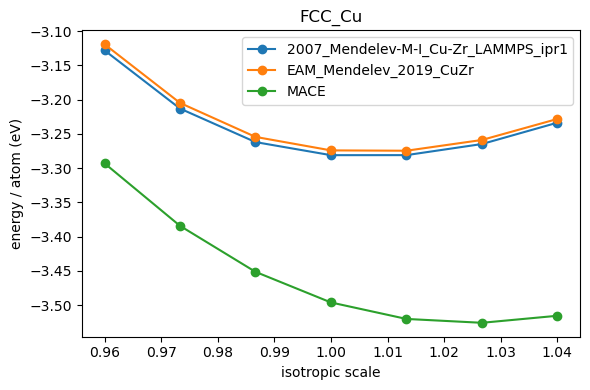

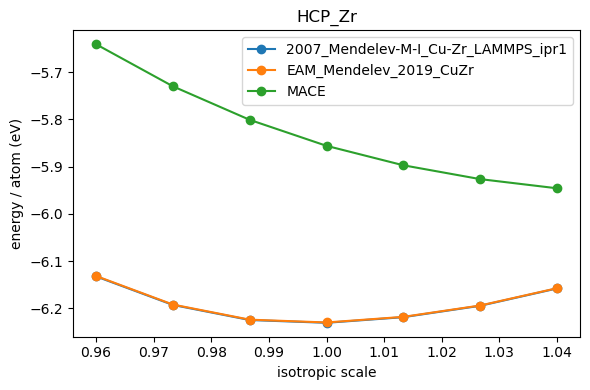

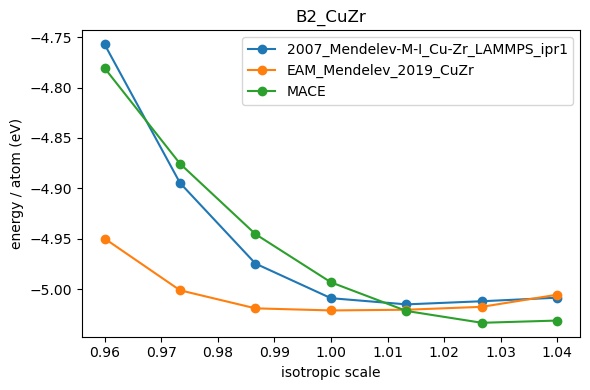

In [11]:
print(eos_df.to_string())

import matplotlib.pyplot as plt

for structure_name in ["FCC_Cu", "HCP_Zr", "B2_CuZr"]:
    sub = eos_df[eos_df["structure"] == structure_name]
    plt.figure(figsize=(6, 4))
    for pid, g in sub.groupby("pot_id"):
        plt.plot(g["scale"], g["energy_per_atom_eV"], marker="o", label=pid)
    plt.xlabel("isotropic scale")
    plt.ylabel("energy / atom (eV)")
    plt.title(structure_name)
    plt.legend()
    plt.tight_layout()
    plt.show()


## 10. Amorphous / NCL-oriented validation pipeline

This is the part closest to your actual science:
- static sanity
- melt
- quench schedule
- minimize
- short NVE drift check
- optional isotropic compression

For now this is still a **workflow-validation** stage because the MACE model is a DEV model.


In [21]:
def md_from_last(pr, job_name, prev_job, pot_spec, T, steps, timestep_fs=1.0, cores=CORES,
                 thermo=THERMO, dump_every=DUMP_EVERY, neigh_every=NEIGH_EVERY):
    struct = prev_job.get_structure(iteration_step=-1)
    return cz.run_md(
        pr=pr,
        job_name=job_name,
        structure=struct,
        pot_spec=pot_spec,
        T=T,
        steps=steps,
        timestep_fs=timestep_fs,
        cores=cores,
        delete_existing=True,
        thermo=thermo,
        dump_every=dump_every,
        neigh_every=neigh_every,
    )

def run_nve(pr, job_name, structure, pot_spec, steps=NVE_STEPS, timestep_fs=1.0, cores=CORES, thermo=THERMO):
    job = cz.make_lammps_job(pr, job_name, structure, pot_spec, delete_existing=False, cores=cores)
    job.calc_md(temperature=None, pressure=None, n_ionic_steps=steps, time_step=timestep_fs)
    job.input.control["fix___ensemble"] = "all nve"
    job.input.control["variable___thermotime"] = f"equal {int(thermo)}"
    job.input.control["neighbor"] = "2.0 bin"
    job.input.control["neigh_modify"] = f"every {int(NEIGH_EVERY)} delay 0 check yes"
    job = cz.load_or_run(pr, job)
    return job

def run_minimize(pr, job_name, structure, pot_spec, cores=CORES):
    job = cz.make_lammps_job(pr, job_name, structure, pot_spec, delete_existing=False, cores=cores)
    job.calc_minimize(ionic_energy_tolerance=0.0, ionic_force_tolerance=1e-4, max_iter=200, n_print=100)
    job = cz.load_or_run(pr, job)
    return job

def ncl_validation_pipeline(pr, structure0, pot_spec):
    out = {"pot_id": pot_spec["id"], "n_atoms": len(structure0)}

    # static sanity
    j0 = cz.run_static(pr, jname("static_glass_seed", pot_spec), structure0, pot_spec, cores=CORES, delete_existing=False)
    out["E_static_per_atom_eV"] = get_last_energy(j0) / len(structure0)

    # melt
    jm = cz.run_md(
        pr=pr,
        job_name=jname("melt", pot_spec),
        structure=structure0,
        pot_spec=pot_spec,
        T=T_MELT,
        steps=STEPS_MELT,
        timestep_fs=1.0,
        cores=CORES,
        delete_existing=False,
        thermo=THERMO,
        dump_every=DUMP_EVERY,
        neigh_every=NEIGH_EVERY,
    )
    out["E_melt_per_atom_eV"] = get_last_energy(jm) / len(structure0)
    out["T_melt_last_K"] = get_last_temp(jm)

    prev = jm
    for T in QUENCH_TS:
        jq = md_from_last(
            pr=pr,
            job_name=jname(f"quench_{T}K", pot_spec),
            prev_job=prev,
            pot_spec=pot_spec,
            T=T,
            steps=STEPS_EACH,
        )
        out[f"E_{T}K_per_atom_eV"] = get_last_energy(jq) / len(structure0)
        out[f"T_{T}K_last_K"] = get_last_temp(jq)
        prev = jq

    # minimize final glass
    jmin = run_minimize(pr, jname("glass_min", pot_spec), prev.get_structure(iteration_step=-1), pot_spec, cores=CORES)
    out["E_glass_min_per_atom_eV"] = get_last_energy(jmin) / len(structure0)

    # short NVE drift check
    jnve = run_nve(pr, jname("glass_nve", pot_spec), jmin.get_structure(iteration_step=-1), pot_spec)
    out["E_nve_per_atom_eV"] = get_last_energy(jnve) / len(structure0)
    out["T_nve_last_K"] = get_last_temp(jnve)

    # optional simple compression test
    compressed = isotropic_scale(jmin.get_structure(iteration_step=-1), 0.97)
    jcomp = cz.run_static(
        pr=pr,
        job_name=jname("glass_compressed", pot_spec),
        structure=compressed,
        pot_spec=pot_spec,
        cores=CORES,
        delete_existing=True,
    )
    out["E_compressed_per_atom_eV"] = get_last_energy(jcomp) / len(compressed)

    return out


## 11. Run the amorphous / NCL-oriented pipeline


In [22]:
ncl_rows = []
for p in POTS_TO_RUN:
    print("RUNNING NCL PIPELINE:", p["id"])
    ncl_rows.append(ncl_validation_pipeline(pr, glass_seed, p))

ncl_df = pd.DataFrame(ncl_rows)
ncl_df


2026-03-13 14:47:16,628 - pyiron_log - WARNING - The job dev_static_glass_seed_MACE is being loaded instead of running. To re-run use the argument 'delete_existing_job=True in create_job'
/var/folders/09/74gqwrwx7391krdz_my0m6r00000gn/T/ipykernel_2661/3566256981.py:3: DeprecationWarning: pyiron_atomistics.atomistics.structure.has_structure.HasStructure.get_structure(iteration_step=-1) is deprecated.
  struct = prev_job.get_structure(iteration_step=-1)
2026-03-13 14:47:16,718 - pyiron_log - WARNING - Job 'dev_quench_1200K_MACE' does not exist and cannot be loaded


RUNNING NCL PIPELINE: MACE
The job dev_quench_1200K_MACE was saved and received the ID: 121


/var/folders/09/74gqwrwx7391krdz_my0m6r00000gn/T/ipykernel_2661/3566256981.py:3: DeprecationWarning: pyiron_atomistics.atomistics.structure.has_structure.HasStructure.get_structure(iteration_step=-1) is deprecated.
  struct = prev_job.get_structure(iteration_step=-1)
2026-03-13 15:15:54,560 - pyiron_log - WARNING - Job 'dev_quench_600K_MACE' does not exist and cannot be loaded


The job dev_quench_600K_MACE was saved and received the ID: 122


/var/folders/09/74gqwrwx7391krdz_my0m6r00000gn/T/ipykernel_2661/3566256981.py:3: DeprecationWarning: pyiron_atomistics.atomistics.structure.has_structure.HasStructure.get_structure(iteration_step=-1) is deprecated.
  struct = prev_job.get_structure(iteration_step=-1)
2026-03-13 15:42:00,936 - pyiron_log - WARNING - Job 'dev_quench_300K_MACE' does not exist and cannot be loaded


...

/var/folders/09/74gqwrwx7391krdz_my0m6r00000gn/T/ipykernel_2661/3566256981.py:79: DeprecationWarning: pyiron_atomistics.atomistics.structure.has_structure.HasStructure.get_structure(iteration_step=-1) is deprecated.
  jnve = run_nve(pr, jname("glass_nve", pot_spec), jmin.get_structure(iteration_step=-1), pot_spec)
2026-03-13 17:58:14,679 - pyiron_log - WARNING - Job 'dev_glass_nve_2007_MendelevmMmI_CumZr_LAMMPS_ipr1' does not exist and cannot be loaded


The job dev_glass_nve_2007_MendelevmMmI_CumZr_LAMMPS_ipr1 was saved and received the ID: 141


/var/folders/09/74gqwrwx7391krdz_my0m6r00000gn/T/ipykernel_2661/3566256981.py:84: DeprecationWarning: pyiron_atomistics.atomistics.structure.has_structure.HasStructure.get_structure(iteration_step=-1) is deprecated.
  compressed = isotropic_scale(jmin.get_structure(iteration_step=-1), 0.97)


The job dev_glass_compressed_2007_MendelevmMmI_CumZr_LAMMPS_ipr1 was saved and received the ID: 142


,pot_id,n_atoms,E_static_per_atom_eV,E_melt_per_atom_eV,T_melt_last_K,E_1200K_per_atom_eV,T_1200K_last_K,E_600K_per_atom_eV,T_600K_last_K,E_300K_per_atom_eV,T_300K_last_K,E_glass_min_per_atom_eV,E_nve_per_atom_eV,T_nve_last_K,E_compressed_per_atom_eV
0,MACE,256,-4.993326,-4.722402,1952.478869,-4.842325,1087.259515,-4.919894,547.005792,-4.956473,264.807234,-4.993326,-4.993326,4.519956e-08,-4.854262
1,EAM_Mendelev_2019_CuZr,256,-5.021244,-4.813532,2045.657279,-4.910195,1140.031460,-4.970751,565.062357,-4.999153,275.100751,-5.036035,-5.036035,3.993650e-08,-4.957977
2,2007_Mendelev-M-I_Cu-Zr_LAMMPS_ipr1,256,-5.009081,-4.777876,2036.192436,-4.892042,1210.568181,-4.949644,588.849116,-4.979543,285.440015,-5.014783,-5.014783,3.193943e-08,-4.835858


## 12. What this notebook currently validates

This notebook now covers:

- **smoke validation**
- **crystalline EOS-style validation**
- **amorphous workflow validation**
- **NCL-oriented melt/quench/minimize/NVE prototype**

It does **not yet** cover:
- final ACE comparison (until ACE is trained)
- structure factor / RDF / Voronoi analysis
- vacancy formation energies / elastic constants
- final paper-quality NCL production runs

Those can be added incrementally once the production MACE and ACE models are ready.


## 13. Additional validation protocols for Paper 1

The cells below **extend** the existing notebook without changing any earlier workflow.

They add a compact set of extra validation protocols motivated by the broader ACE validation literature, while still keeping the scope aligned with **Paper 1**:

- crystalline mechanical / EOS-derived parameters
- vacancy formation energetics
- amorphous RDF sanity check
- optional structure-factor proxy
- concise summary table for NCL-oriented readiness

These are still **validation** calculations.  
They are **not** the full MD-DMS / NCL production study, which belongs to Paper 2.


## 14. Bulk modulus estimate from the existing EOS scans

We reuse the already computed `eos_df` and estimate the bulk modulus around the minimum
from a local quadratic fit of energy vs volume.

This is intentionally lightweight:
- it does not replace a full equation-of-state publication analysis
- but it adds a useful mechanical sanity check for FCC Cu, HCP Zr, and B2 CuZr


In [ ]:
import numpy as np
import pandas as pd

EV_PER_A3_TO_GPA = 160.21766208

def get_structure_volume(structure):
    return float(abs(np.linalg.det(np.array(structure.cell))))

def local_bulk_modulus_from_eos(structure, eos_slice):
    df = eos_slice.sort_values("scale").copy()
    if len(df) < 3:
        return np.nan

    V0 = get_structure_volume(structure)
    df["volume_A3"] = V0 * (df["scale"].astype(float) ** 3)
    x = df["volume_A3"].to_numpy(dtype=float)
    y = df["energy_last_eV"].to_numpy(dtype=float)

    i0 = int(np.argmin(y))
    lo = max(0, i0 - 1)
    hi = min(len(df), i0 + 2)

    # expand to at least 3 points if possible
    if hi - lo < 3:
        lo = max(0, hi - 3)
        hi = min(len(df), lo + 3)

    xfit = x[lo:hi]
    yfit = y[lo:hi]
    if len(xfit) < 3:
        return np.nan

    a, b, c = np.polyfit(xfit, yfit, 2)
    if a <= 0:
        return np.nan

    vmin = -b / (2 * a)
    b0_eva3 = vmin * (2 * a)
    return b0_eva3 * EV_PER_A3_TO_GPA

structure_map = {
    "FCC_Cu": fcc_cu,
    "HCP_Zr": hcp_zr,
    "B2_CuZr": b2_cuzr,
}

bulk_rows = []
for pot_id in sorted(eos_df["pot_id"].unique()):
    for sname, structure in structure_map.items():
        sub = eos_df[(eos_df["pot_id"] == pot_id) & (eos_df["structure"] == sname)].copy()
        bulk_rows.append({
            "pot_id": pot_id,
            "structure": sname,
            "bulk_modulus_GPa_est": local_bulk_modulus_from_eos(structure, sub),
        })

bulk_df = pd.DataFrame(bulk_rows)
bulk_df


## 15. Vacancy formation energies

A defect-energy test is useful because it probes local energetics more strongly than EOS alone.

Here we compute a **compact vacancy validation** for:
- FCC Cu
- HCP Zr

The implementation is intentionally simple:
1. build a supercell,
2. compute the perfect-cell energy,
3. remove one atom,
4. relax the defective structure,
5. estimate the vacancy formation energy

For a pure element:
\[
E_f^{vac} = E_{defect} - \frac{N-1}{N} E_{perfect}
\]


In [ ]:
def make_vacancy_structure(structure, atom_index=0):
    s = structure.copy()
    del s[atom_index]
    return s

def vacancy_formation_energy(pr, base_structure, structure_name, pot_spec, repeat=(3, 3, 3), atom_index=0):
    perfect = base_structure.repeat(repeat)

    jperf = run_minimize(
        pr,
        jname(f"vac_perfect_{structure_name}", pot_spec),
        perfect,
        pot_spec,
        cores=CORES,
    )
    e_perfect = get_last_energy(jperf)
    n_perfect = len(jperf.structure)

    defect = make_vacancy_structure(jperf.get_structure(iteration_step=-1), atom_index=atom_index)
    jdef = run_minimize(
        pr,
        jname(f"vac_defect_{structure_name}", pot_spec),
        defect,
        pot_spec,
        cores=CORES,
    )
    e_defect = get_last_energy(jdef)

    e_form = e_defect - ((n_perfect - 1) / n_perfect) * e_perfect
    return {
        "pot_id": pot_spec["id"],
        "structure": structure_name,
        "repeat": "x".join(map(str, repeat)),
        "n_perfect": n_perfect,
        "e_vac_form_eV": e_form,
    }

vac_rows = []
vacuum_targets = [
    ("FCC_Cu", fcc_cu, (4, 4, 4)),
    ("HCP_Zr", hcp_zr, (4, 4, 3)),
]

for p in POTS_TO_RUN:
    print("VACANCY:", p["id"])
    for sname, structure, rep in vacuum_targets:
        try:
            vac_rows.append(vacancy_formation_energy(pr, structure, sname, p, repeat=rep))
        except Exception as exc:
            vac_rows.append({
                "pot_id": p["id"],
                "structure": sname,
                "repeat": "x".join(map(str, rep)),
                "n_perfect": np.nan,
                "e_vac_form_eV": np.nan,
                "error": str(exc),
            })

vac_df = pd.DataFrame(vac_rows)
vac_df


## 16. Amorphous RDF sanity check

Paper 1 does not need a full amorphous-structure analysis chapter, but it is useful to
include at least one compact structural sanity check on the final glass.

We therefore compute the radial distribution function (RDF) for the minimized glass
obtained in the melt–quench pipeline.


In [ ]:
import matplotlib.pyplot as plt
from ase.geometry.analysis import Analysis

def safe_last_structure(job):
    try:
        return job.get_structure(iteration_step=-1)
    except Exception:
        return job.get_structure()

rdf_store = {}

plt.figure(figsize=(6, 4))
for p in POTS_TO_RUN:
    pid = p["id"]
    try:
        jmin = pr.load(jname("glass_min", p))
        s = safe_last_structure(jmin)
        ana = Analysis(s)
        r, g = ana.get_rdf(rmax=8.0, nbins=200)
        rdf_store[pid] = {"r": np.asarray(r), "g_r": np.asarray(g)}
        plt.plot(r, g, label=pid)
    except Exception as exc:
        print(f"RDF skipped for {pid}: {exc}")

plt.xlabel("r (Å)")
plt.ylabel("g(r)")
plt.title("RDF of minimized Cu–Zr glass")
plt.legend()
plt.show()


## 17. Optional structure-factor proxy from RDF

If desired, we can compute a lightweight total-structure-factor proxy from the RDF.

This is **not** a full experimental scattering workflow, but it is often useful as an
additional amorphous-structure comparison plot.

You may skip this section if the RDF already provides enough evidence for Paper 1.


In [ ]:
def structure_factor_from_rdf(r, g_r, rho_number, q_values):
    r = np.asarray(r, dtype=float)
    g_r = np.asarray(g_r, dtype=float)
    q_values = np.asarray(q_values, dtype=float)

    h = g_r - 1.0
    s_q = []

    for q in q_values:
        if q == 0:
            s_q.append(np.nan)
            continue
        integrand = r * h * np.sin(q * r)
        integral = np.trapz(integrand, r)
        s_q.append(1.0 + 4.0 * np.pi * rho_number * integral / q)

    return np.asarray(s_q)

plt.figure(figsize=(6, 4))
q_grid = np.linspace(0.5, 16.0, 300)

for p in POTS_TO_RUN:
    pid = p["id"]
    if pid not in rdf_store:
        continue
    try:
        jmin = pr.load(jname("glass_min", p))
        s = safe_last_structure(jmin)
        volume = get_structure_volume(s)
        rho = len(s) / volume
        sq = structure_factor_from_rdf(rdf_store[pid]["r"], rdf_store[pid]["g_r"], rho, q_grid)
        plt.plot(q_grid, sq, label=pid)
    except Exception as exc:
        print(f"S(q) skipped for {pid}: {exc}")

plt.xlabel("q (1/Å)")
plt.ylabel("S(q) proxy")
plt.title("Approximate structure-factor comparison")
plt.legend()
plt.show()


## 18. Integrated summary table for Paper 1

This final table collects the main validation outputs in one place and is meant to support
the eventual narrative of Paper 1:

- crystalline EOS / modulus sanity
- defect energetics
- amorphous workflow completion
- short NVE stability
- amorphous structural sanity


In [ ]:
def get_nve_drift_for_potential(pot_id):
    if "ncl_df" not in globals():
        return np.nan
    sub = ncl_df[ncl_df["pot_id"] == pot_id]
    if len(sub) == 0:
        return np.nan
    try:
        return float(sub["E_nve_per_atom_eV"].iloc[0] - sub["E_glass_min_per_atom_eV"].iloc[0])
    except Exception:
        return np.nan

summary_rows = []
for p in POTS_TO_RUN:
    pid = p["id"]

    bulk_vals = bulk_df[bulk_df["pot_id"] == pid].set_index("structure")["bulk_modulus_GPa_est"].to_dict()
    vac_vals = vac_df[vac_df["pot_id"] == pid].set_index("structure")["e_vac_form_eV"].to_dict()

    summary_rows.append({
        "pot_id": pid,
        "bulk_FCC_Cu_GPa_est": bulk_vals.get("FCC_Cu", np.nan),
        "bulk_HCP_Zr_GPa_est": bulk_vals.get("HCP_Zr", np.nan),
        "bulk_B2_CuZr_GPa_est": bulk_vals.get("B2_CuZr", np.nan),
        "vac_FCC_Cu_eV": vac_vals.get("FCC_Cu", np.nan),
        "vac_HCP_Zr_eV": vac_vals.get("HCP_Zr", np.nan),
        "glass_pipeline_done": bool(pid in set(ncl_df["pot_id"])) if "ncl_df" in globals() else False,
        "rdf_available": pid in rdf_store,
        "nve_energy_shift_per_atom_eV": get_nve_drift_for_potential(pid),
    })

paper1_validation_df = pd.DataFrame(summary_rows)
paper1_validation_df
